In [1]:
import os

#add the root directory
os.chdir('../')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from PCAfold import normalized_variance_derivative, cost_function_normalized_variance_derivative
import numpy as np
import pandas as pd
import torch
from loader import *
import matplotlib.pyplot as plt
import h5py
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from utils import *
from tools import *
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from matplotlib.patches import Ellipse
import matplotlib.colors as colors

logging.disable(logging.CRITICAL) #disable the logging

# Supplementary material S2.2.3: Encoder-decoder with vs. without the trainable scaling layer on flamelet dataset </Br>
Comparison and analysis of encoder-decoders with and without the scaling layer prior to the encoder.

In [ ]:
namesWithout_flamelet = ["lin", "Log", "linLog", "linLogH2O2HO2","linLogNONO2"]
namesWith_flamelet = ["35a_Yuki_v2_noLog_R1", "35a_Yuki_v2_Log_R1", "35a_Yuki_v2_linLog_R1", "Yuki_v2_RMSprop_250_linLogH2O2HO2","Yuki_v2_RMSprop_250_linLogNONO2"]

MSE_NN_without_flamelet = []
MSE_NN_with_flamelet = []

path_MSE_NN = "paper/data/"

my_seed = 7
lr = 0.01

for nameWithout, nameWith in zip(namesWithout_flamelet, namesWith_flamelet):
    MSE_NN_without_flamelet.append(np.load(f"{path_MSE_NN}MSE_val_NN_TrYuki_v2_noScale_RMSprop_250_{nameWithout}_flamelet-Yuki-v2_s{my_seed}.npy"))
    MSE_NN_with_flamelet.append(np.load(f"{path_MSE_NN}MSE_val_NN_Tr{nameWith}_flamelet-Yuki-v2_s{my_seed}.npy"))

MSE_NN_without_flamelet = np.array(MSE_NN_without_flamelet).flatten().tolist()
MSE_NN_with_flamelet = np.array(MSE_NN_with_flamelet).flatten().tolist()

# remove outliers
MSE_NN_with_flamelet.pop(0)

names_without_flamelet = ["lin", "Log", "linLog", "linLogH2O2HO2","linLogNONO2"] 
names_with_flamelet = ["35a_Yuki_v2_noLog_R1", "35a_Yuki_v2_Log_R1", "35a_Yuki_v2_linLog_R1", "Yuki_v2_RMSprop_250_linLogH2O2HO2","Yuki_v2_RMSprop_250_linLogNONO2"]

cost_avg_without_flamelet = []
cost_avg_with_flamelet = []

cost_PVsource_without_flamelet = []
cost_PVsource_with_flamelet = []

for i in range(len(names_with_flamelet)):
    for j in range(10):
        
        CostsW_flamelet = np.load(f"data-files/costs/costs_TrYuki_v2_noScale_RMSprop_250_{names_without_flamelet[i]}_s{j}-bw_-6_2_100-p_4-ver_sh_1-dataset_flamelet-Yuki-v2.npy")
        Costs_flamelet = np.load(f"data-files/costs/costs_Tr{names_with_flamelet[i]}_s{j}-bw_-6_2_100-p_4-ver_sh_1-dataset_flamelet-Yuki-v2.npy")

        cost_avg_without_flamelet.append(compute_avg(CostsW_flamelet))
        cost_avg_with_flamelet.append(compute_avg(Costs_flamelet))

        cost_PVsource_without_flamelet.append(CostsW_flamelet[-1])
        cost_PVsource_with_flamelet.append(Costs_flamelet[-1])

#remove outliers
#with: remove index 0
cost_avg_with_flamelet.pop(0)
cost_PVsource_with_flamelet.pop(0)

5.576629709821234

<div class="alert alert-block alert-danger"><b>Note: </b>One point has been removed as outliers (↑).  
The corresponding encoder–decoder models converged to poor parametrizations due to unfavorable random initialization of the weights.</div>

## MSE vs. cost for parametrizations obtained with encoders-decoders with and without the trainable scaling layer for flamelet dataset

C:\Windows\Temp\ipykernel_2876\2835738573.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')
C:\Windows\Temp\ipykernel_2876\2835738573.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[0].scatter(MSE_NN_without_flamelet, cost_avg_without_flamelet, label="Without scaling layer",
C:\Windows\Temp\ipykernel_2876\2835738573.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & 

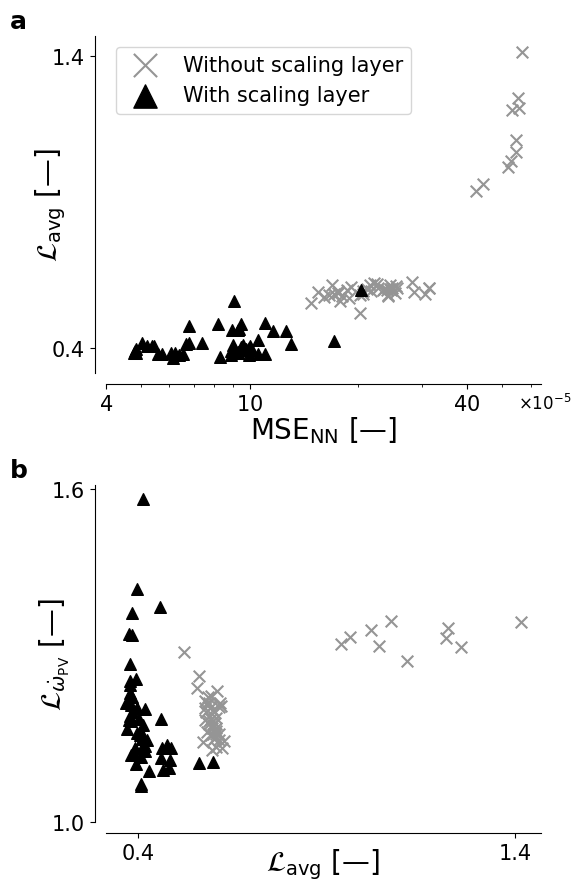

In [4]:
save = True
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/Flamelet-Yuki/"
name = f"Suppl. mat. - flamelet Yuki v2 - MSE vs cost - with vs. without scaling layer"

fig, ax = plt.subplots(
    2, 1,
    figsize=(6, 9),
    sharex=False,
    sharey=False
)

def plot_figure_1(ax):
    size_marker = 70
    greys = cm.get_cmap('Greys')

    # --- Top subplot (a) ---
    ax[0].scatter(MSE_NN_without_flamelet, cost_avg_without_flamelet, label="Without scaling layer",
                  c=greys(0.5), marker="x", s=size_marker)
    ax[0].scatter(MSE_NN_with_flamelet, cost_avg_with_flamelet, label="With scaling layer",
                  c="k", marker="^", s=size_marker)

    ax[0].set_xlabel(r'$\mathrm{MSE}_{\mathrm{NN}}$ [—]', fontsize=20, labelpad=0)
    ax[0].set_ylabel(r'$\mathcal{L}_{\mathrm{avg}}$ [—]', fontsize=20, labelpad = -12)
    ax[0].legend(fontsize=15, scatterpoints=1, markerscale=2)
    ax[0].set_xscale("log")
    ax[0].set_xticks([0.00004, 0.0001, 0.0004])
    ax[0].set_xticklabels([r'$4$', r'$10$', r'$40$'], fontsize=15)
    ax[0].set_yticks([0.4, 1.4])
    ax[0].tick_params(axis='y', labelsize=15)
    ax[0].xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x*10**5:g}")
    )
    ax[0].text(1.07, -0.09, r'$\times 10^{-5}$',
               transform=ax[0].transAxes, fontsize=12,
               va='center', ha='right')

    # --- Bottom subplot (b) ---
    ax[1].scatter(cost_avg_without_flamelet, cost_PVsource_without_flamelet,
                  c=greys(0.5), marker="x", s=size_marker)
    ax[1].scatter(cost_avg_with_flamelet, cost_PVsource_with_flamelet,
                  c="k", marker="^", s=size_marker)

    ax[1].set_xlabel(r'$\mathcal{L}_{\mathrm{avg}}$ [—]', fontsize=20, labelpad=-12)
    ax[1].set_ylabel(r'$\mathcal{L}_{\dot{\omega}_{\mathrm{PV}}}$ [—]', fontsize=20, labelpad = -15)
    ax[1].set_xticks([0.4, 1.4])
    ax[1].set_yticks([1, 1.6])
    ax[1].tick_params(axis='both', labelsize=15)

    # Spine cleanup
    for a in ax:
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        a.spines['left'].set_position(('outward', 8))
        a.spines['bottom'].set_position(('outward', 8))
        a.tick_params(direction="out")

    ax[0].set_xticklabels([r'$4$', r'$10$', r'$40$'], fontsize=15)


def add_panel_label(ax, label, x_offset=-0.12, y_offset=1.08, fontsize=18):
    ax.text(
        x_offset, y_offset,
        label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )


# Plot panels a and b
plot_figure_1(ax)

add_panel_label(ax[0], "a", x_offset = -0.22)
add_panel_label(ax[1], "b", x_offset = -0.22)

plt.tight_layout()

if save:
    plt.savefig(pathSave + name + ".png", dpi=1000, bbox_inches="tight")
    plt.savefig(pathSave + name + ".pdf", bbox_inches="tight")

plt.show()